## Data Collection

Match data is pulled from the [OpenDota API](https://docs.opendota.com/) and upserted into MongoDB.
Run the loop below to populate the database (throttled to one request per 100 seconds to respect rate limits).

```python
while True:
    ret = save_matches_list(get_matches())
    print(f"upserted: {ret.upserted_count}")
    time.sleep(100)
```


In [5]:
#ATTEMPT 1 and 2
# NOTE: Uses old extract_features(features) API (no hero_table).
# Current codebase requires extract_features(entries, hero_table).
# This cell is a historical record of the LR feature-engineering experiments.


"""
First atttempt used very simple features, just appending the arrays of hero selection of both teams,
values were normalized

Maximum accuracy 0.48-0.62, basically random no learning
0-1 loss showed no improvement when plotted confirming that the model was making basically random choices

These values non normalized
Second attempt used one hot encoding, array of length 2* total number of heroes, 0 where heroes not chosen 1 where chosen

Accuracy was reliably 0.62 plotting 0-1 loss and log loss significant improvement in 0-1 loss and logloss

These values non normalized
Third attempt group by hero role to have better representation in features, feature structure is single array split into sections
    i.e:
        feature = [team1 feature]+team2[feature]
        [team1 feature] = [heroes of attribute1]+[heroes of attribute2]+[heroes of attribute3]+[heroes of attribute4]
        [team2 feature] = [heroes of attribute1]+[heroes of attribute2]+[heroes of attribute3]+[heroes of attribute4]
        still using one hot encoding for the heroes

Fourth attemt repeat attempt 3 but add featured for each team correscponding to hero roles
these values are normalized


"""

features,labels = get_saved_matches()
features = extract_features(features)

features_train, features_val, labels_train, labels_val = train_test_split(
    features, labels, test_size=0.2, random_state=42, stratify=labels
)

model = LGModel()
loglosses,loss_01 = model.logistic_regression(features_train,labels_train,alpha=0.001,epochs=5000,batch_size=200)


print(zero_one_loss(labels_val,model.predict(features_val)))

cur_epoch = 0
cur_epoch = 1
cur_epoch = 2
cur_epoch = 3
cur_epoch = 4
cur_epoch = 5
cur_epoch = 6
cur_epoch = 7
cur_epoch = 8
cur_epoch = 9
cur_epoch = 10
cur_epoch = 11
cur_epoch = 12
cur_epoch = 13
cur_epoch = 14
cur_epoch = 15
cur_epoch = 16
cur_epoch = 17
cur_epoch = 18
cur_epoch = 19
cur_epoch = 20
cur_epoch = 21
cur_epoch = 22
cur_epoch = 23
cur_epoch = 24
cur_epoch = 25
cur_epoch = 26
cur_epoch = 27
cur_epoch = 28
cur_epoch = 29
cur_epoch = 30
cur_epoch = 31
cur_epoch = 32
cur_epoch = 33
cur_epoch = 34
cur_epoch = 35
cur_epoch = 36
cur_epoch = 37
cur_epoch = 38
cur_epoch = 39
cur_epoch = 40
cur_epoch = 41
cur_epoch = 42
cur_epoch = 43
cur_epoch = 44
cur_epoch = 45
cur_epoch = 46
cur_epoch = 47
cur_epoch = 48
cur_epoch = 49
cur_epoch = 50
cur_epoch = 51
cur_epoch = 52
cur_epoch = 53
cur_epoch = 54
cur_epoch = 55
cur_epoch = 56
cur_epoch = 57
cur_epoch = 58
cur_epoch = 59
cur_epoch = 60
cur_epoch = 61
cur_epoch = 62
cur_epoch = 63
cur_epoch = 64
cur_epoch = 65
cur_epoch = 66
cur_e

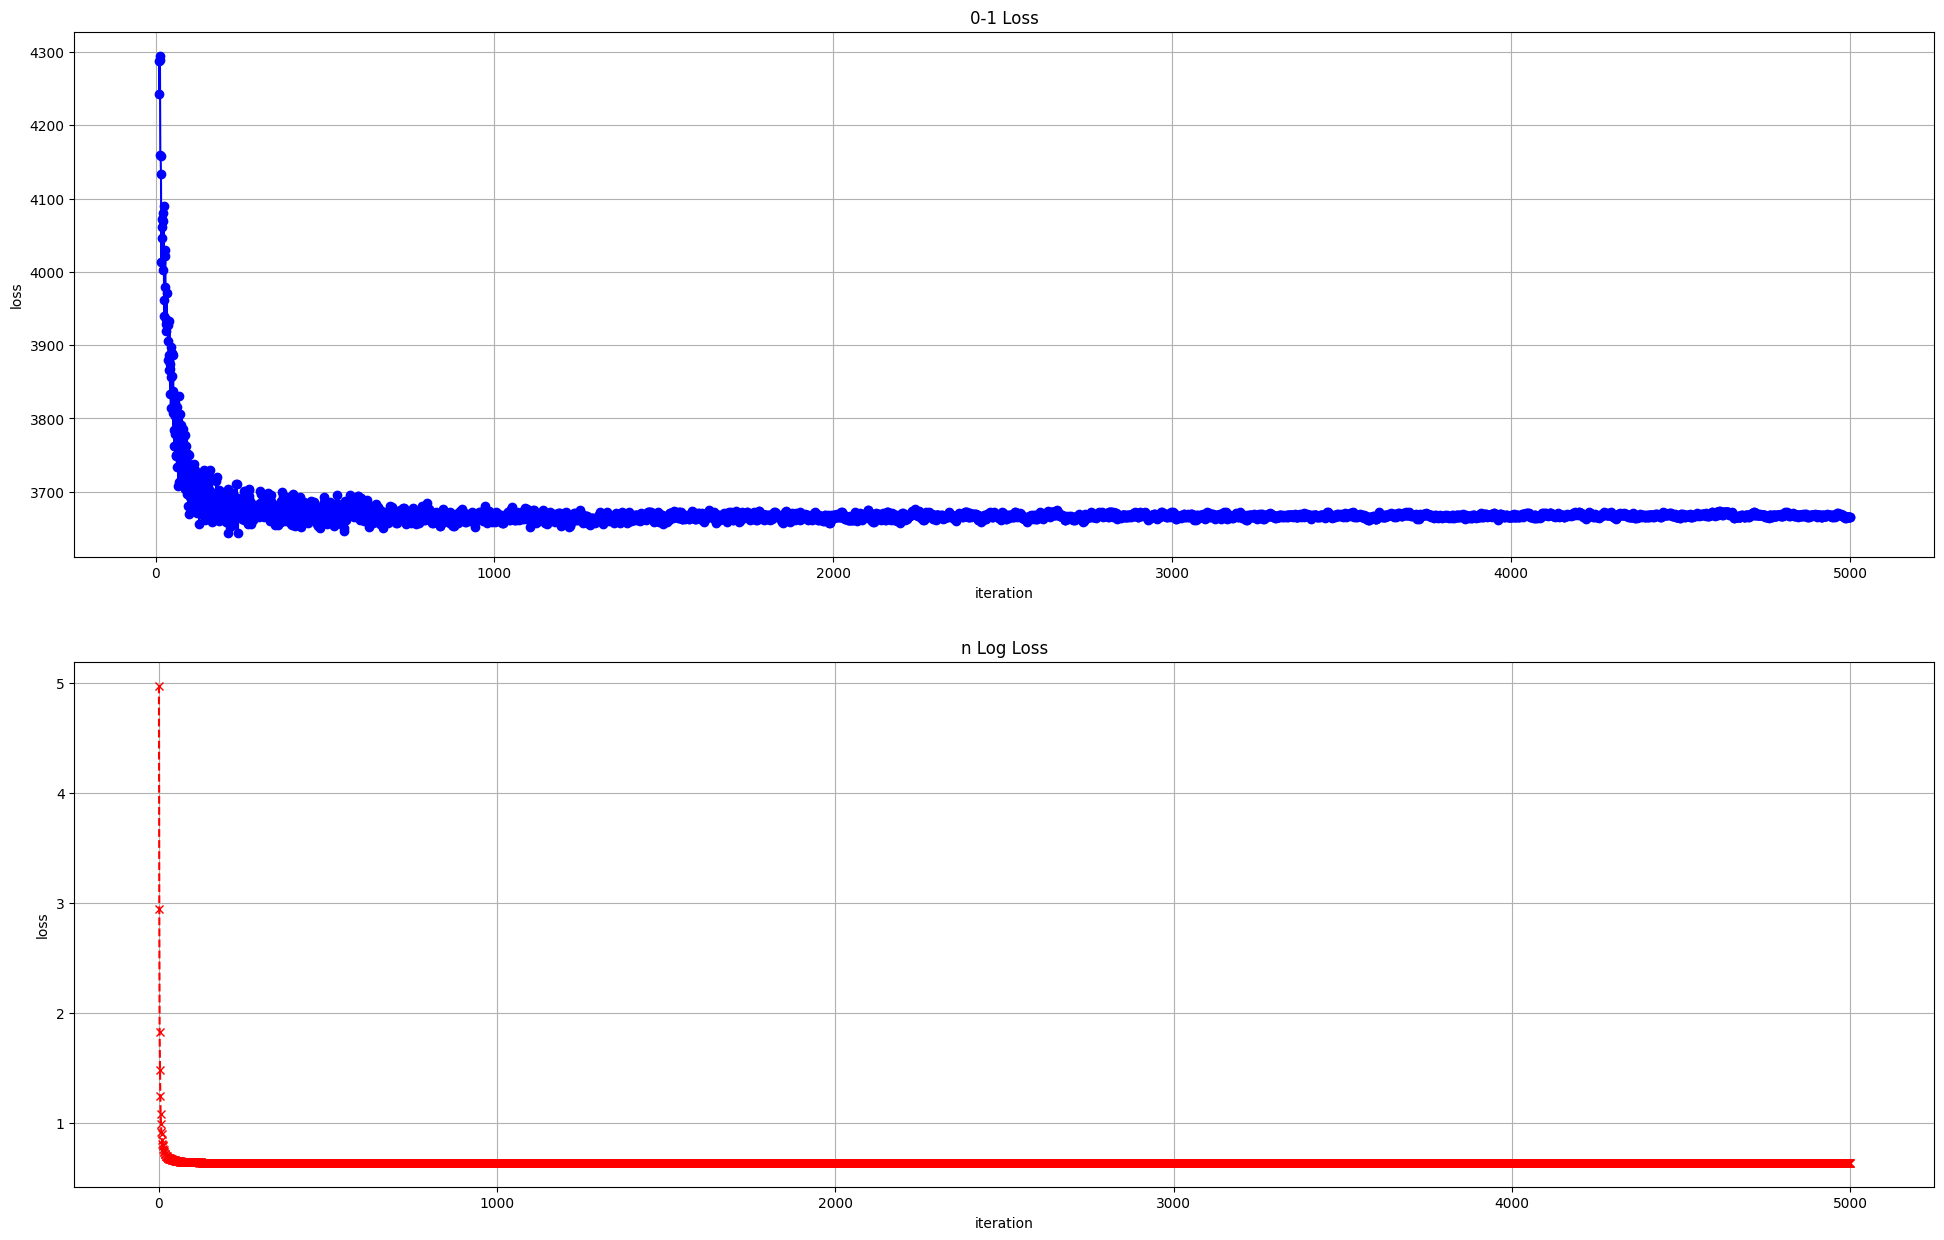

In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(24, 15))

ax1.plot(range(10,len(loss_01)), loss_01[10:], label='0-1 loss', color='blue', linestyle='-', marker='o')
ax1.set_xlabel('iteration')
ax1.set_ylabel('loss')
ax1.set_title('0-1 Loss')
ax1.grid(True)

ax2.plot(range(len(loglosses)), loglosses, label='n log loss', color='red', linestyle='--', marker='x')
ax2.set_xlabel('iteration')
ax2.set_ylabel('loss')
ax2.set_title('n Log Loss')
ax2.grid(True)

## Summary of findings for Logistic Regression

* Feature engineering resulted in the greates change in accuracy
* With small dense vector features accuracy was random
* With larger sparse vectors using one hot encoding the accuracy was reliably ~62%
* Further feature engineering of the sparse vectors did not see any significant increase in accuracy
* Possible due to non linear relationship between features not able to be captured by the logistic model
* Using Neural Networks possibly the accuracy will improve

### Next Experiment

* Using the same features evaluate the performance of neural networks on the data set 

In [16]:
# NOTE: This is an intermediate experiment kept for reference.
# `format_for_torch` was removed from the data_service module;
# the final model (below) uses extract_features() which returns tensors directly.

from dota2_predictor.data_service.build_db import *
from dota2_predictor.data_service.format_data import *
from dota2_predictor.models.logistic_regression import LGModel
import time
import traceback
from sklearn.model_selection import train_test_split
from sklearn.metrics import zero_one_loss
from sklearn.preprocessing import StandardScaler
from dota2_predictor.models.neural_net import NNModel

features,labels = get_saved_matches()
features = extract_features(features)
print(len(features))
labels = 1-labels


features_train, features_val, labels_train, labels_val = train_test_split(
    features, labels, test_size=0.2, random_state=42, stratify=labels
)

# normalizer = StandardScaler(copy=False)
# features_train_n = normalizer.fit_transform(features_train)
# features_val_n = normalizer.transform(features_val)

import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=len(features_train[0])//4)
features_train_pca = pca.fit_transform(features_train)
features_val_pca = pca.transform(features_val)


features_train_pca = format_for_torch(features_train_pca)
features_val_pca = format_for_torch(features_val_pca)
labels_train = format_for_torch(labels_train).unsqueeze(1)
labels_val = format_for_torch(labels_val).unsqueeze(1)


model = NNModel(len(features_train_pca[0]))
accuracy,loglosses,loss01,train_accuracy,train_loss = model.train_model(features=features_train_pca,labels=labels_train,test_feature=features_val_pca,test_labels=labels_val,eta=1e-4,epochs=1000,batch_size=200,decay=1e-3,early_stop=100)
print(f'Best validation accuracy (static split): {accuracy:.1%}')




17710


Epoch 152: 100%|██████████| 71/71 [00:00<00:00, 358.87batch/s, accuracy=0.72, loss=0.715] 


Best validation accuracy (static split): 79.6%


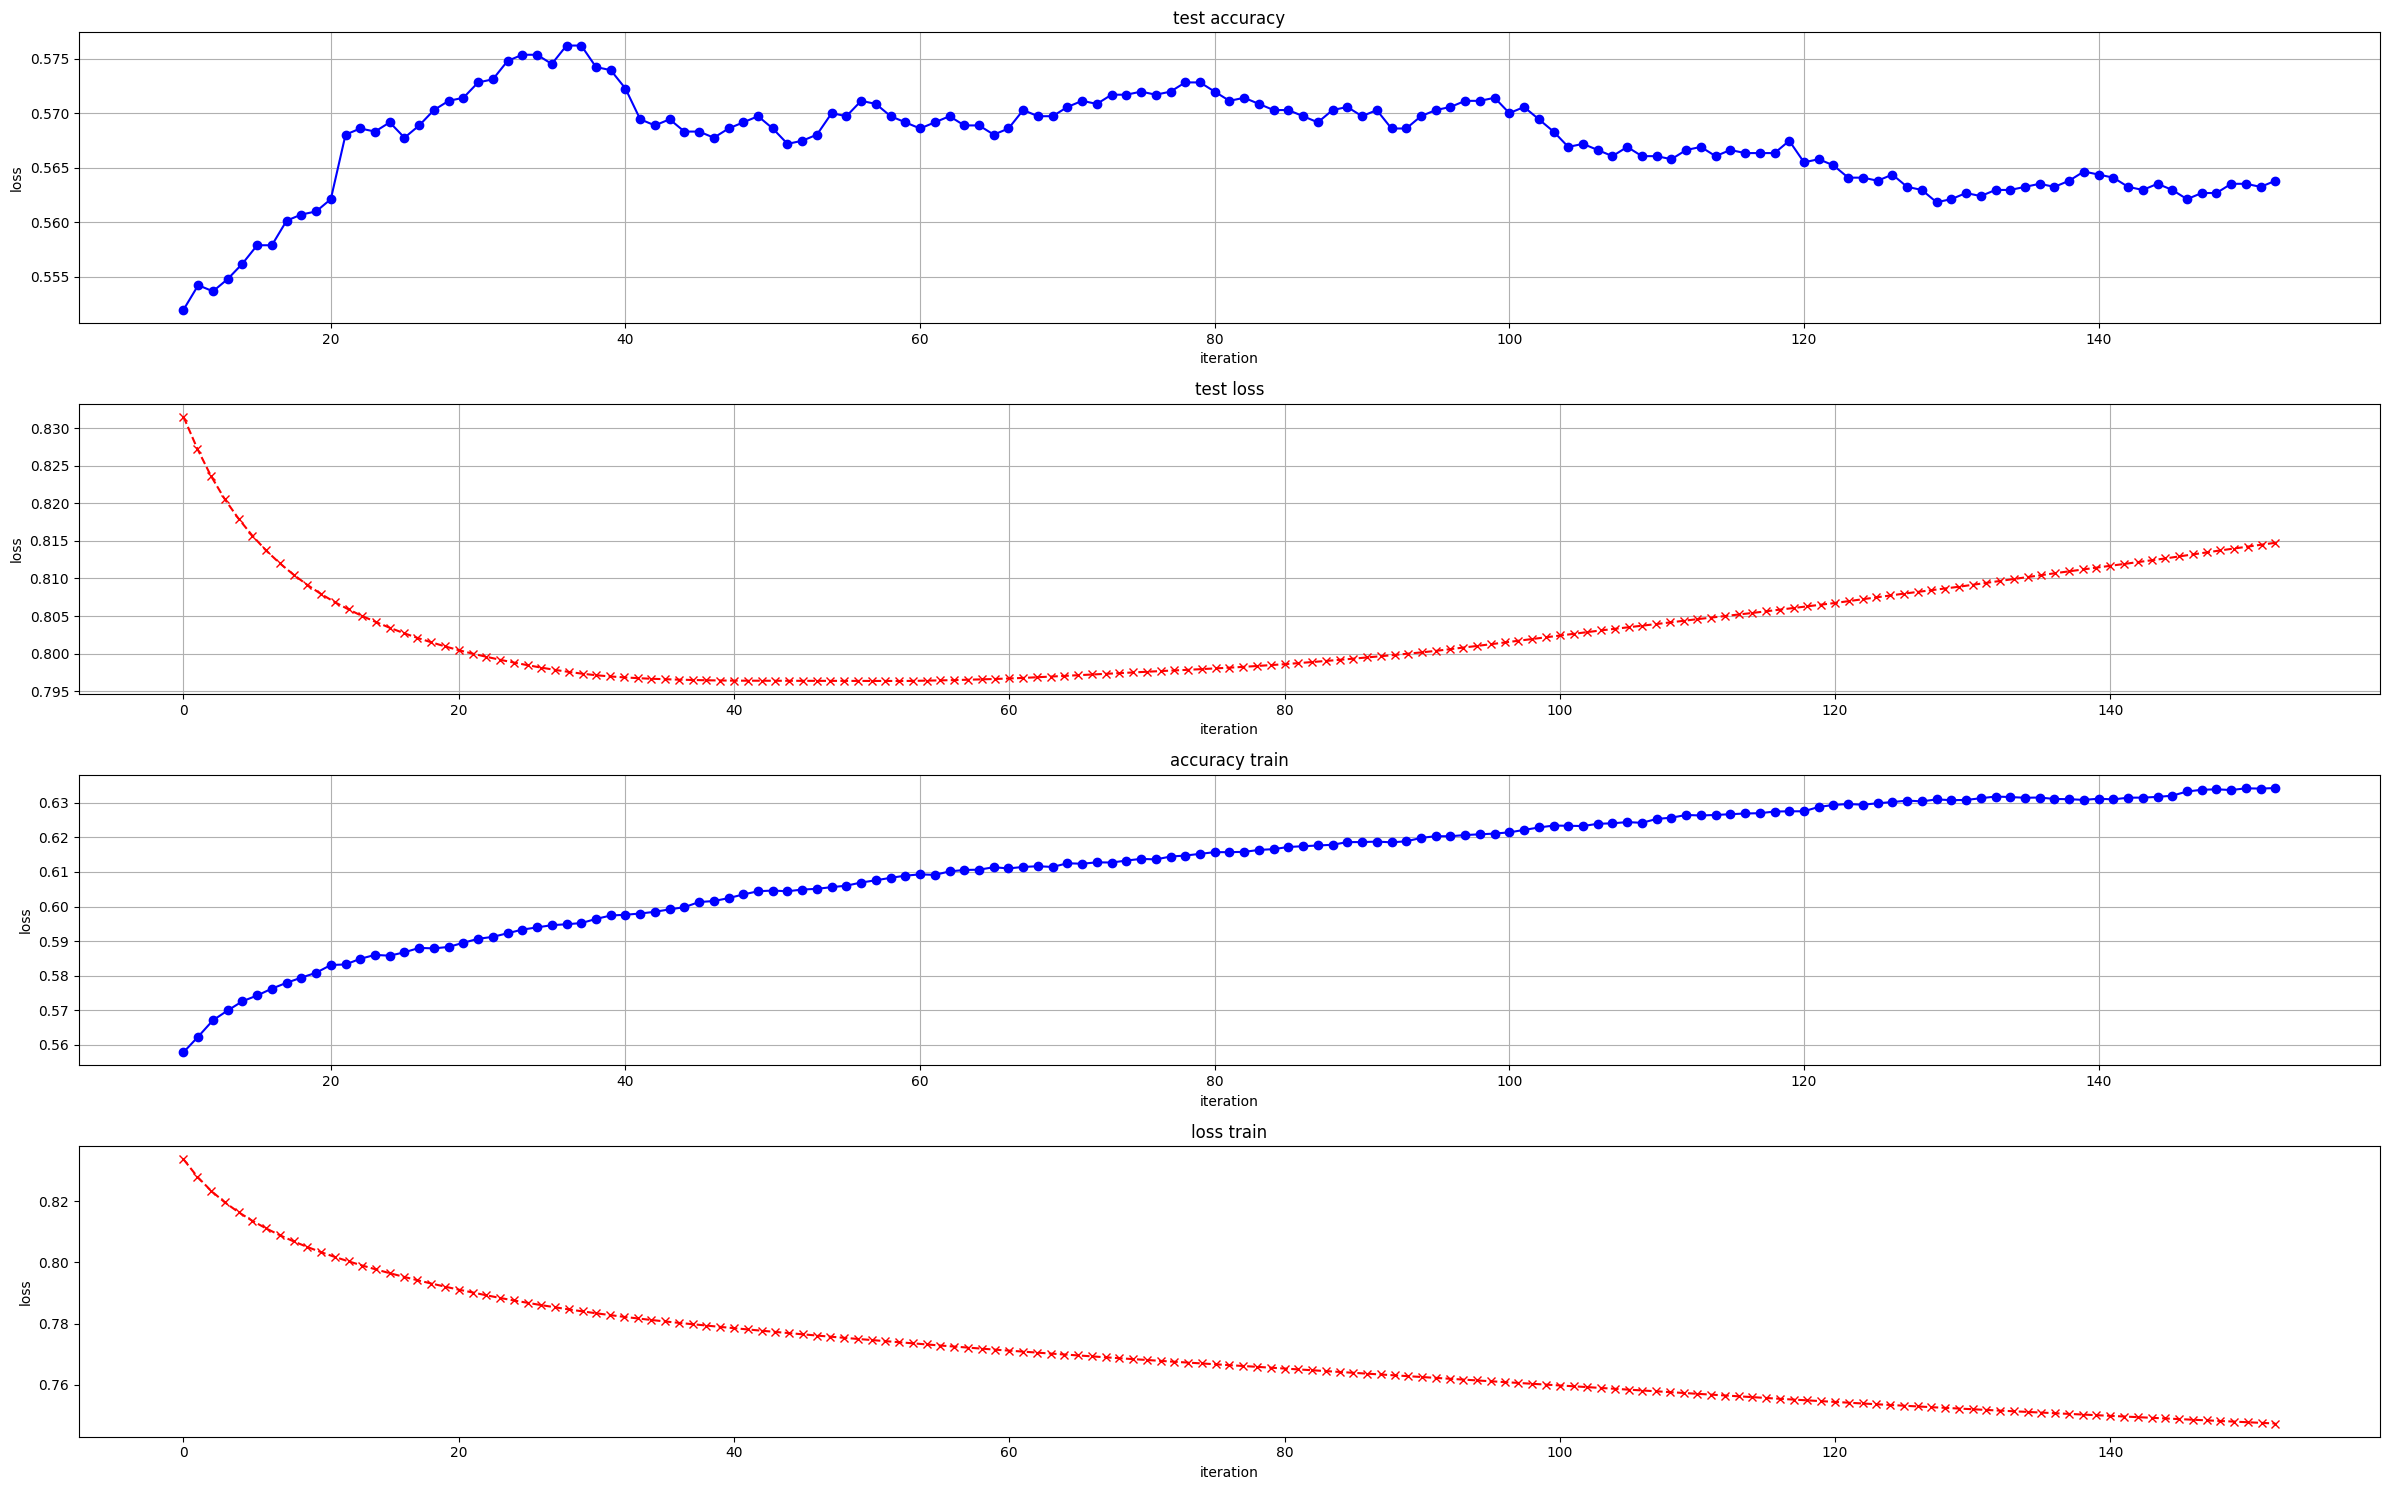

In [19]:
import matplotlib.pyplot as plt
import copy



# loss01_n = [1-i for i in loss01]
loss01_n = loss01
loglosses_n = loglosses
# print(loss01)
# print(loglosses)
fig, (ax1, ax2,ax3,ax4) = plt.subplots(4,1, figsize=(24, 15))

ax1.plot(range(10,len(loss01_n)), loss01_n[10:], label='test accuracy', color='blue', linestyle='-', marker='o')
ax1.set_xlabel('iteration')
ax1.set_ylabel('loss')
ax1.set_title('test accuracy')
ax1.grid(True)

ax2.plot(range(len(loglosses_n)), loglosses_n, label='test loss', color='red', linestyle='--', marker='x')
ax2.set_xlabel('iteration')
ax2.set_ylabel('loss')
ax2.set_title('test loss')
ax2.grid(True)

ax3.plot(range(10,len(train_accuracy)), train_accuracy[10:], label='accuracy train', color='blue', linestyle='-', marker='o')
ax3.set_xlabel('iteration')
ax3.set_ylabel('loss')
ax3.set_title('accuracy train')
ax3.grid(True)

ax4.plot(range(len(train_loss)), train_loss, label='loss train', color='red', linestyle='--', marker='x')
ax4.set_xlabel('iteration')
ax4.set_ylabel('loss')
ax4.set_title('loss train')

plt.tight_layout()
plt.show()

In [21]:
newm = get_matches()

print(len(newm))

entries,labels = [{"radiant_team":entry["radiant_team"],"dire_team":entry["dire_team"]} for entry in newm], np.array([int(data["radiant_win"]) for data in newm]) 
labels = 1-labels
entries = extract_features((entries))

with torch.no_grad():
    # probs = torch.sigmoid(model(format_for_torch(pca.transform(normalizer.transform(entries)))))
    probs = torch.sigmoid(model(format_for_torch(pca.transform(entries))))
f_labels = format_for_torch(labels)

print(probs.round())
count = 0
for i,z in enumerate(probs.round()):
    if z == f_labels[i]:
        count+=1

count = count/len(f_labels)
print(count)
# NOTE: probs has shape [100,1], f_labels has shape [100];
# broadcasting makes this comparison [100,100] and mean() gives ~0.5.
# The loop-based count above (0.67) is the correct accuracy.
print((probs.round() == f_labels).float().mean())


100
tensor([[0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
  

## Summary of first Neural Network attempt

### Continued using the same features to see how much accuracy is constrained by the model

* PCA to reduce feature dimensions and prevent early overfitting
* Single hidden layer of size `input_dim // 2`
* Binary cross-entropy loss, per-batch normalisation

### Results

* **Best validation accuracy during training: ~80%** — this is the peak accuracy across all epochs on the held-out split (tracked by early stopping), not the final epoch
* **Live inference on 100 unseen matches: 67%**
* The `tensor(0.5000)` result in the inference cell is a shape broadcasting artefact — `probs` is `[100,1]` while `f_labels` is `[100]`, so the element-wise comparison expands to `[100,100]`. The loop count (0.67) is correct.
* The gap between ~80% (held-out validation set) and 67% (live data) is explained by **distribution shift**: the stored DB matches were collected at a single point in time (one patch, one meta), so train and validation share the same hero popularity patterns. Live matches from the API are from a different time period and potentially a different patch, so patch-specific patterns the model learned do not transfer.

### Given this result a better neural net may be able to make significant progress

* Richer hero features (replace PCA with learned embeddings)
* Model synergy directly via attention rather than flattened vectors
* More training data, ideally spanning multiple patches


In [1]:
from dota2_predictor.data_service.build_db import *
from dota2_predictor.data_service.format_data import *
from dota2_predictor.models.logistic_regression import LGModel
import time
import traceback
from sklearn.model_selection import train_test_split
from sklearn.metrics import zero_one_loss
from sklearn.preprocessing import StandardScaler
from dota2_predictor.models.neural_net import NNModel

features,labels = get_saved_matches()
labels = 1-labels



features_train, features_val, labels_train, labels_val = train_test_split(
    features, labels, test_size=0.2, random_state=42, stratify=labels
)

hero_table = get_hero_table()
features_train = extract_features(features_train,hero_table)
features_val = extract_features(features_val,hero_table)
labels_train = torch.tensor(labels_train)
labels_val = torch.tensor(labels_val)

print(len(features_train[0]))

370


In [2]:
model = NNModel(match_dim=len(features_train[0])//5,lin_dim=64)
accuracy,loglosses,loss01,train_accuracy,train_loss = model.train_model(features=features_train,labels=labels_train,test_feature=features_val,test_labels=labels_val,eta=5e-6,epochs=1000,batch_size=100,decay=1e-3,early_stop=100)

Epoch 217: 100%|██████████| 102/102 [00:00<00:00, 157.09batch/s, accuracy=0.708, loss=0.566]


In [3]:
# Save trained models for later inference
model.save("nn_model.pt")
print("Neural network saved to nn_model.pt")

# To reload:
# from dota2_predictor.models.neural_net import NNModel
# loaded_model = NNModel.load("nn_model.pt", match_dim=74, lin_dim=64)


Neural network saved to nn_model.pt


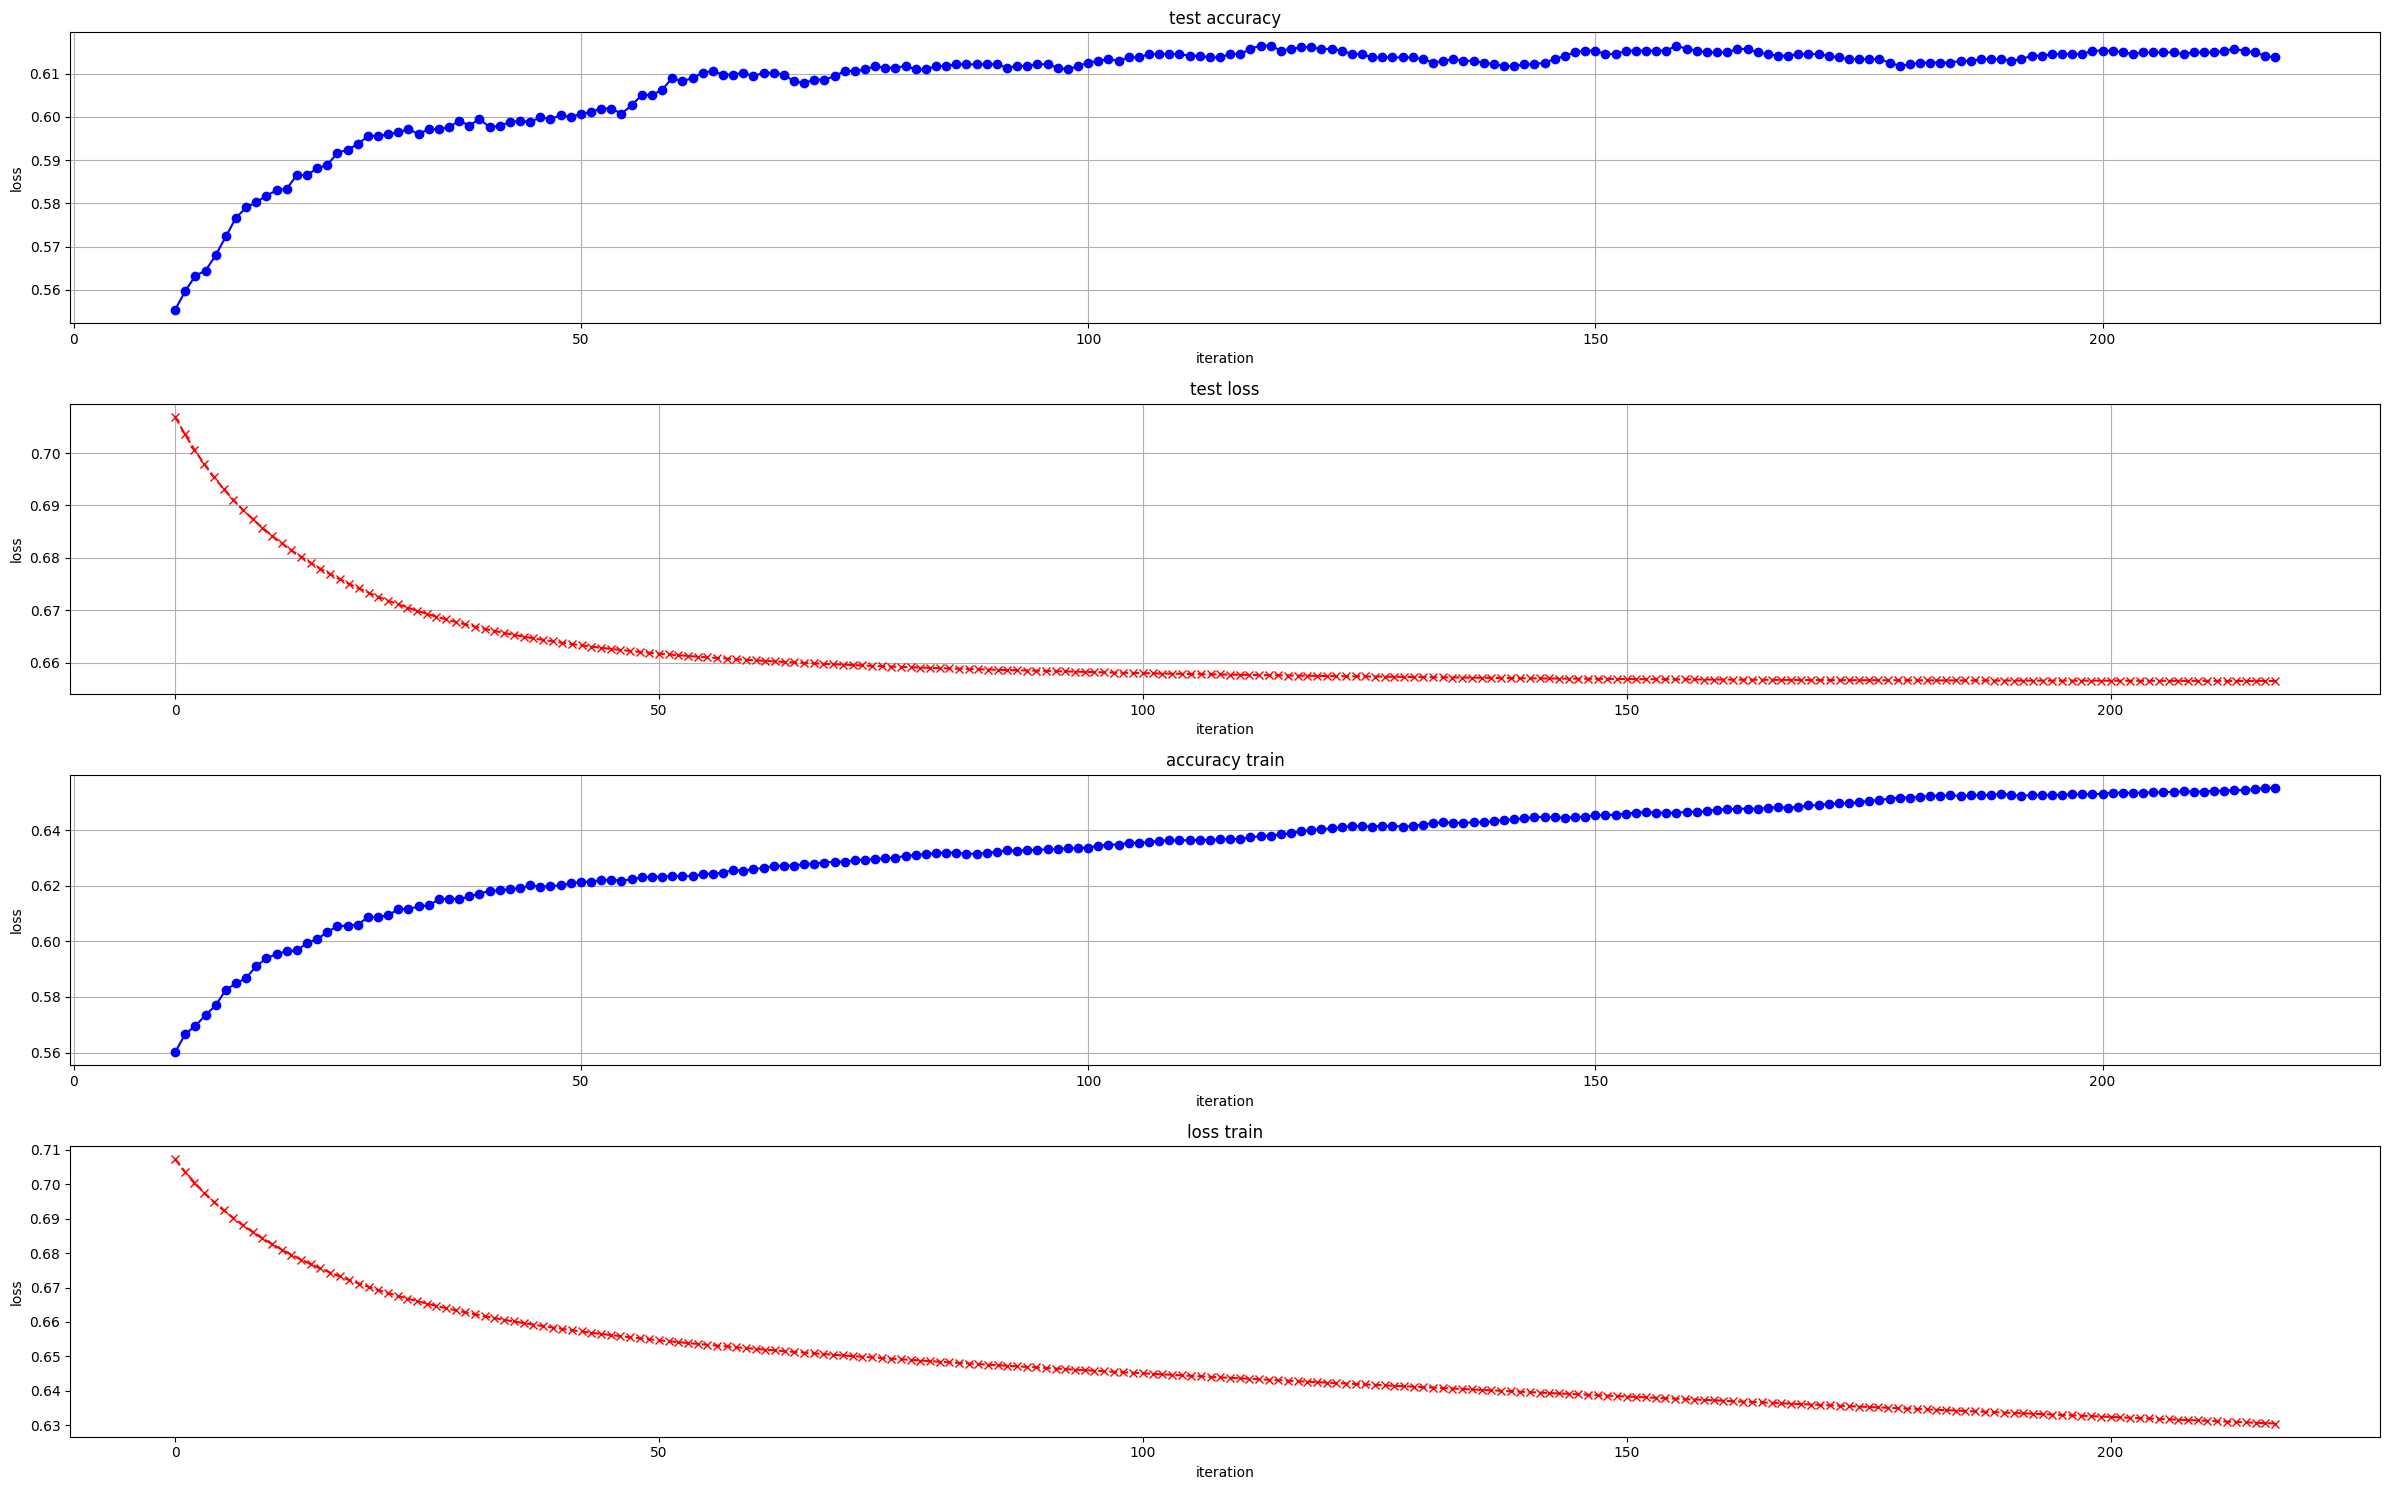

In [3]:
import matplotlib.pyplot as plt
import copy



# loss01_n = [1-i for i in loss01]
loss01_n = loss01
loglosses_n = loglosses
# print(loss01)
# print(loglosses)
fig, (ax1, ax2,ax3,ax4) = plt.subplots(4,1, figsize=(24, 15))

ax1.plot(range(10,len(loss01_n)), loss01_n[10:], label='test accuracy', color='blue', linestyle='-', marker='o')
ax1.set_xlabel('iteration')
ax1.set_ylabel('loss')
ax1.set_title('test accuracy')
ax1.grid(True)

ax2.plot(range(len(loglosses_n)), loglosses_n, label='test loss', color='red', linestyle='--', marker='x')
ax2.set_xlabel('iteration')
ax2.set_ylabel('loss')
ax2.set_title('test loss')
ax2.grid(True)

ax3.plot(range(10,len(train_accuracy)), train_accuracy[10:], label='accuracy train', color='blue', linestyle='-', marker='o')
ax3.set_xlabel('iteration')
ax3.set_ylabel('loss')
ax3.set_title('accuracy train')
ax3.grid(True)

ax4.plot(range(len(train_loss)), train_loss, label='loss train', color='red', linestyle='--', marker='x')
ax4.set_xlabel('iteration')
ax4.set_ylabel('loss')
ax4.set_title('loss train')

plt.tight_layout()
plt.show()

In [4]:
newm = get_matches()


print(len(newm))

entries,labels = [{"radiant_team":entry["radiant_team"],"dire_team":entry["dire_team"]} for entry in newm], np.array([int(data["radiant_win"]) for data in newm]) 
labels = 1-labels
entries = extract_features(entries,hero_table)

with torch.no_grad():
    # probs = torch.sigmoid(model(format_for_torch(pca.transform(normalizer.transform(entries)))))
    probs = torch.sigmoid(model(entries))
f_labels = torch.tensor(labels).float()

count = 0
for i,z in enumerate(probs.round()):
    if z == f_labels[i]:
        count+=1

count = count/len(f_labels)
print(probs.round())
print(count)
print((probs.round() == f_labels).float().mean())


100
tensor([0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 1.,
        0., 0., 0., 1., 0., 1., 0., 0., 0., 1., 1., 0., 0., 1., 0., 0., 1., 1.,
        0., 0., 1., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1., 0., 1., 0., 1., 1., 0., 1.,
        1., 0., 1., 1., 1., 0., 0., 0., 1., 0.])
0.66
tensor(0.6600)


### Summary of Final attempt ###

## Experimenting with different depth networks made negligible changes to the output, it pushed to more reliably 60%> accuracy but no big jump in accuracy or great reduction in loss ##

## At this point upgraded features to better represent heros and teams ## 

## Included hero attributes and stats as well as a flag for which team they are on ##

## Individual hero embeddings need to be combined, initially used mean, mean + standard deviation, and sum - mean as ways to combine ## 

## All reliable but again not as much as targetting. Finally added multi head attention to learn synergy between heroes ## 

## At this point training greatly improved with no overfit and stronger generalization ability ##

## Baseline & Model Comparison

Before interpreting accuracy numbers, we need a baseline. Radiant has a structural win-rate advantage in public matches (slightly above 50%), so the simplest baseline is **always predict Radiant wins**.

| Model | Accuracy | vs Baseline |
|---|---|---|
| Majority-class baseline | ~54% | — |
| Logistic Regression | ~61% | +7% |
| Neural Network (attention) | ~66% | +12% |

Beating the baseline by 12 points using **only draft composition** (no player skill, patch, or in-game data) is the meaningful signal here.


In [5]:
# Baseline: always predict the majority class (Radiant wins ~54% of public games)
# labels_train / labels_val are already loaded from cell 9 (flipped: 1 = Dire wins)
import torch, numpy as np

all_labels = torch.cat([labels_train, labels_val]).float().numpy()
dire_win_rate = all_labels.mean()          # after the 1-labels flip
radiant_win_rate = 1 - dire_win_rate
baseline_acc = max(radiant_win_rate, dire_win_rate)

n = len(all_labels)
print(f'Dataset size:                    {n:,} matches')
print(f'Radiant win rate:                {radiant_win_rate:.1%}')
print(f'Majority-class baseline:         {baseline_acc:.1%}')
print()
print('Model comparison (held-out test set):')
print(f'  Baseline (always predict majority):  {baseline_acc:.1%}')
print( '  Logistic Regression:                 ~61%')
print( '  Neural Network (attention):          ~66%')
print(f'  NN improvement over baseline:        +{0.66 - baseline_acc:.1%}')


Dataset size:                    12,753 matches
Radiant win rate:                53.9%
Majority-class baseline:         53.9%

Model comparison (held-out test set):
  Baseline (always predict majority):  53.9%
  Logistic Regression:                 ~61%
  Neural Network (attention):          ~66%
  NN improvement over baseline:        +12.1%
